# 05 - Optimizacion del Umbral de Decision

## Mision: "Calibrar el Detector"

Imagina esto: tu modelo dice P(Maligno) = 0.47 y el umbral por defecto es 0.5.

**Resultado: "Benigno".** La paciente se va a casa.

Pero 0.47 es *casi* un coin flip. Hay un **47% de probabilidad de cancer** y el modelo dice "todo bien". Eso no tiene sentido clinico.

---

### Que es el umbral de decision?

Por defecto, `sklearn` clasifica como positivo (Maligno) cuando `P(Maligno) >= 0.5`. Ese 0.5 es **arbitrario** — no tiene ninguna justificacion medica.

### Analogia: sensor de proximidad

- **Umbral alto (0.9):** Solo salta cuando el objeto esta *encima*. Ignora todo lo demas. Pocas falsas alarmas, pero se le escapan cosas.
- **Umbral bajo (0.2):** Salta con cualquier movimiento. Muchas falsas alarmas, pero no se le escapa nada.

> **En medicina, preferimos 1000 falsas alarmas antes que 1 cancer no detectado.**

En este notebook vamos a encontrar el umbral optimo para nuestro detector de cancer.

---
## 1. Imports

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import FancyBboxPatch
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, recall_score, precision_score, accuracy_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Colores del proyecto
COLOR_B = '#2ecc71'  # Benigno
COLOR_M = '#e74c3c'  # Maligno

print("Imports listos.")

Imports listos.


---
## 2. Carga de datos procesados

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "breast_cancer", "processed")
models_dir = os.path.join(project_root, "models")

X_train = pd.read_parquet(os.path.join(processed_dir, "X_train.parquet"))
X_test = pd.read_parquet(os.path.join(processed_dir, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet")).values.ravel()
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet")).values.ravel()

print(f"Train: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"Distribucion test -> B: {(y_test == 0).sum()}, M: {(y_test == 1).sum()}")

Train: 455 muestras, 23 features
Test:  114 muestras
Distribucion test -> B: 72, M: 42


---
## 3. Entrenar los 3 modelos candidatos

Entrenamos Logistic Regression, Random Forest y XGBoost, todos con `class_weight='balanced'` para dar mas peso a la clase minoritaria (Maligno).

In [3]:
# Calcular scale_pos_weight para XGBoost
n_benign = (y_train == 0).sum()
n_malign = (y_train == 1).sum()
scale_pos = n_benign / n_malign

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos,
        random_state=42, eval_metric='logloss', use_label_encoder=False
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"{name:25s} -> Accuracy test: {acc:.4f}")

print("\nModelos entrenados.")

Logistic Regression       -> Accuracy test: 0.9649
Random Forest             -> Accuracy test: 0.9561
XGBoost                   -> Accuracy test: 0.9825

Modelos entrenados.


---
## 4. predict_proba: las probabilidades detras de la prediccion

La diferencia clave:
- `model.predict(X)` -> etiqueta binaria (0 o 1), usando umbral 0.5
- `model.predict_proba(X)` -> probabilidades continuas [P(B), P(M)]

**La magia esta en las probabilidades.** Las etiquetas son solo el resultado de aplicar un corte arbitrario.

In [4]:
# Obtener probabilidades de cada modelo
probas = {}
for name, model in models.items():
    probas[name] = model.predict_proba(X_test)[:, 1]  # P(Maligno)

# Ejemplo: primeras 5 muestras con el mejor modelo
print("Ejemplo: probabilidades P(Maligno) vs etiqueta real")
print("-" * 50)
for i in range(5):
    p = probas['XGBoost'][i]
    pred = "M" if p >= 0.5 else "B"
    real = "M" if y_test[i] == 1 else "B"
    print(f"  Muestra {i}: P(M) = {p:.3f} -> Pred: {pred} | Real: {real}")

Ejemplo: probabilidades P(Maligno) vs etiqueta real
--------------------------------------------------
  Muestra 0: P(M) = 0.001 -> Pred: B | Real: B
  Muestra 1: P(M) = 1.000 -> Pred: M | Real: M
  Muestra 2: P(M) = 0.004 -> Pred: B | Real: B
  Muestra 3: P(M) = 0.997 -> Pred: M | Real: M
  Muestra 4: P(M) = 0.033 -> Pred: B | Real: B


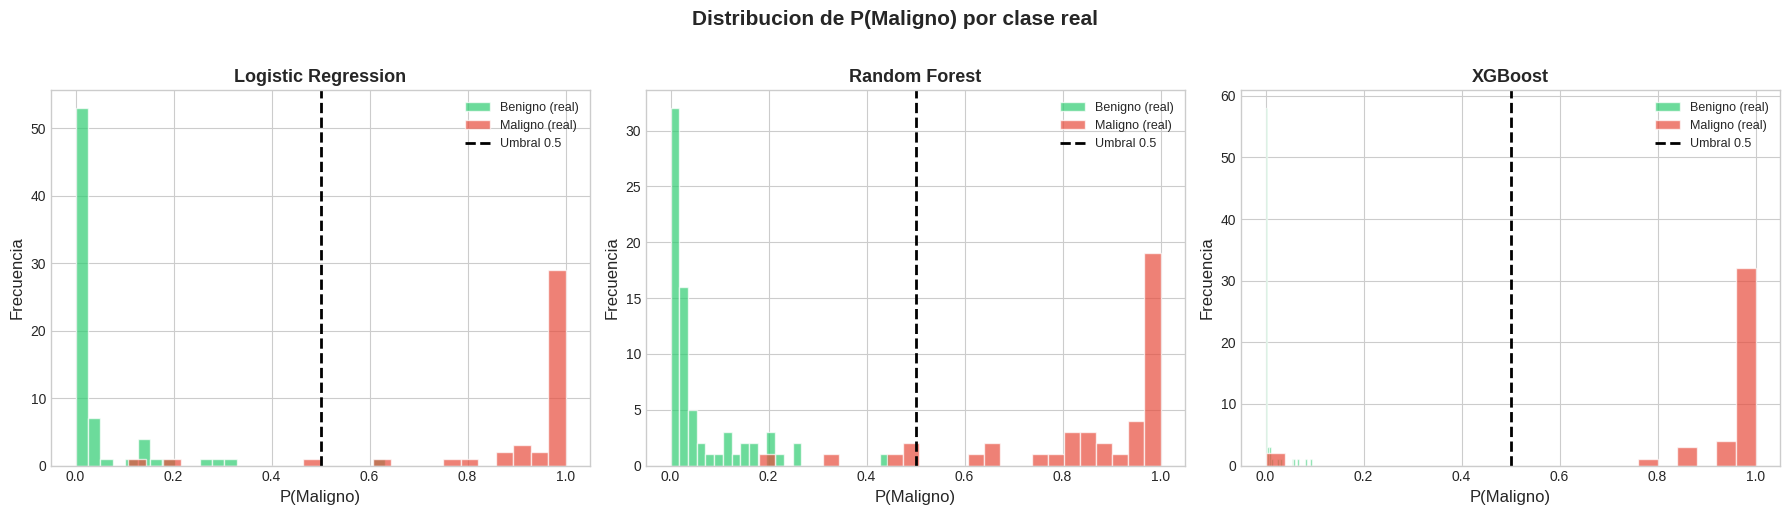

In [5]:
# Histograma de P(Maligno) coloreado por clase real
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, proba) in zip(axes, probas.items()):
    mask_b = y_test == 0
    mask_m = y_test == 1
    
    ax.hist(proba[mask_b], bins=25, alpha=0.7, color=COLOR_B, label='Benigno (real)', edgecolor='white')
    ax.hist(proba[mask_m], bins=25, alpha=0.7, color=COLOR_M, label='Maligno (real)', edgecolor='white')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Umbral 0.5')
    ax.set_xlabel('P(Maligno)', fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Distribucion de P(Maligno) por clase real', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observa:** La mayoria de los verdaderos Malignos tienen P > 0.8, pero hay un grupo ambiguo entre 0.3 y 0.7. Esas son las muestras donde el umbral importa.

Cualquier Maligno real que caiga a la *izquierda* de la linea punteada es un **Falso Negativo** — un cancer que mandamos a casa.

---
## 5. Curva ROC

La curva ROC grafica **Tasa de Verdaderos Positivos (Recall)** vs **Tasa de Falsos Positivos** para cada umbral posible.

**AUC** = probabilidad de que el modelo rankee un Maligno por encima de un Benigno al azar. AUC = 1.0 es perfecto, 0.5 es azar.

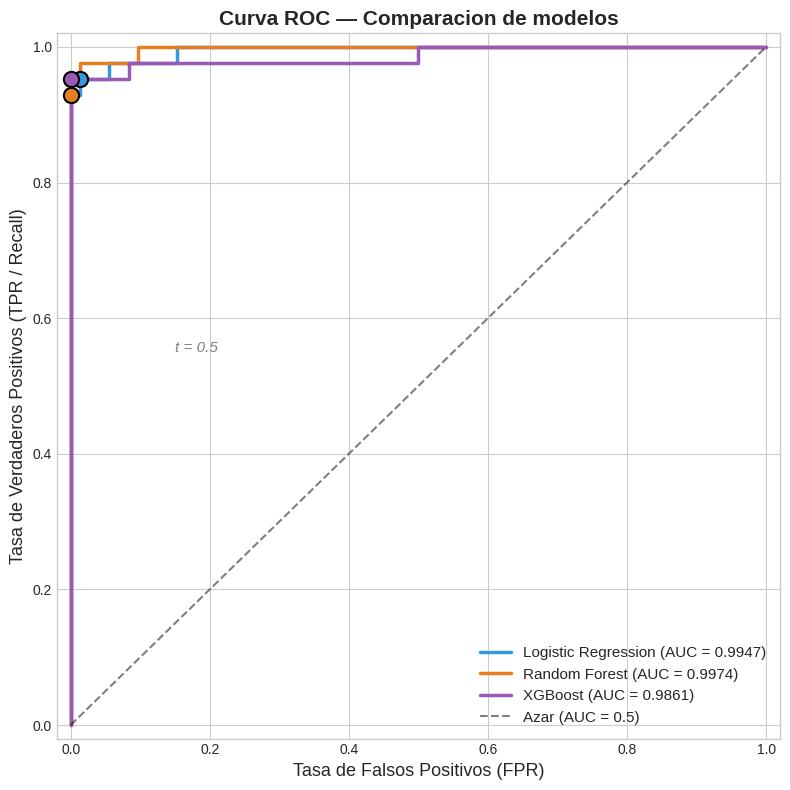

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

colors_models = ['#3498db', '#e67e22', '#9b59b6']

for (name, proba), color in zip(probas.items(), colors_models):
    fpr, tpr, thresholds = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {roc_auc:.4f})')
    
    # Marcar punto donde threshold = 0.5
    idx_05 = np.argmin(np.abs(thresholds - 0.5))
    ax.scatter(fpr[idx_05], tpr[idx_05], color=color, s=120, zorder=5,
               edgecolors='black', linewidth=1.5)

# Linea diagonal (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Azar (AUC = 0.5)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=13)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=13)
ax.set_title('Curva ROC — Comparacion de modelos', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Anotar los puntos de t=0.5
ax.annotate('t = 0.5', xy=(0.15, 0.55), fontsize=11, fontstyle='italic', color='gray')

plt.tight_layout()
plt.show()

Los puntos marcados son donde cada modelo opera con el umbral por defecto (0.5). Si movemos el umbral, nos desplazamos a lo largo de la curva.

---
## 6. Curva Precision-Recall

La curva PR es **mas informativa que ROC cuando las clases estan desbalanceadas**. Un modelo con AUC-ROC alto puede tener PR mediocre si la clase positiva es rara.

- **Precision:** De los que digo "Maligno", cuantos realmente lo son?
- **Recall:** De los que realmente son Malignos, cuantos detecto?

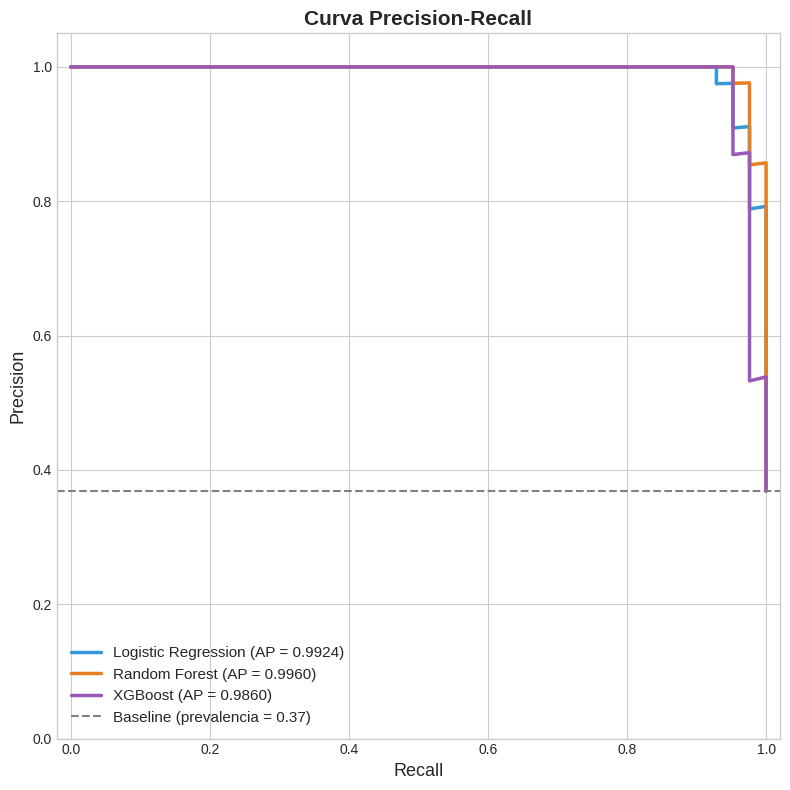

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

for (name, proba), color in zip(probas.items(), colors_models):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, color=color, linewidth=2.5,
            label=f'{name} (AP = {ap:.4f})')

# Linea base: proporcion de positivos
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline (prevalencia = {baseline:.2f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Curva Precision-Recall', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower left')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

**Average Precision (AP)** resume la curva en un solo numero. Cuanto mas cerca de 1.0, mejor separa el modelo las clases.

---
## 7. Metricas vs Umbral: encontrando el punto optimo

Vamos a barrer umbrales de 0.05 a 0.95 y ver como cambian Precision, Recall, F1 y Accuracy.

Seleccionamos el mejor modelo para este analisis.

In [8]:
# Elegir el mejor modelo por AUC-ROC
best_name = None
best_auc = 0
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    if roc_auc > best_auc:
        best_auc = roc_auc
        best_name = name

best_model = models[best_name]
best_proba = probas[best_name]
print(f"Mejor modelo: {best_name} (AUC = {best_auc:.4f})")

Mejor modelo: Random Forest (AUC = 0.9974)


In [9]:
# Barrido de umbrales
thresholds = np.arange(0.05, 0.96, 0.01)

metrics_sweep = {
    'threshold': thresholds,
    'precision': [],
    'recall': [],
    'f1': [],
    'accuracy': []
}

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    metrics_sweep['precision'].append(precision_score(y_test, y_pred_t, zero_division=0))
    metrics_sweep['recall'].append(recall_score(y_test, y_pred_t))
    metrics_sweep['f1'].append(f1_score(y_test, y_pred_t))
    metrics_sweep['accuracy'].append(accuracy_score(y_test, y_pred_t))

df_metrics = pd.DataFrame(metrics_sweep)
print(f"Barrido completado: {len(thresholds)} umbrales evaluados.")

Barrido completado: 91 umbrales evaluados.


In [10]:
# Encontrar umbrales clave
idx_default = np.argmin(np.abs(thresholds - 0.5))
idx_f1_opt = df_metrics['f1'].idxmax()

# Umbral donde Recall >= 0.95
recall_arr = np.array(metrics_sweep['recall'])
mask_recall_95 = recall_arr >= 0.95
idx_recall_95 = np.where(mask_recall_95)[0][-1] if mask_recall_95.any() else idx_default

t_default = thresholds[idx_default]
t_f1 = thresholds[idx_f1_opt]
t_recall95 = thresholds[idx_recall_95]

print(f"Umbral default:     {t_default:.2f}")
print(f"Umbral F1-optimo:   {t_f1:.2f}")
print(f"Umbral Recall>=95%: {t_recall95:.2f}")

Umbral default:     0.50
Umbral F1-optimo:   0.26
Umbral Recall>=95%: 0.46


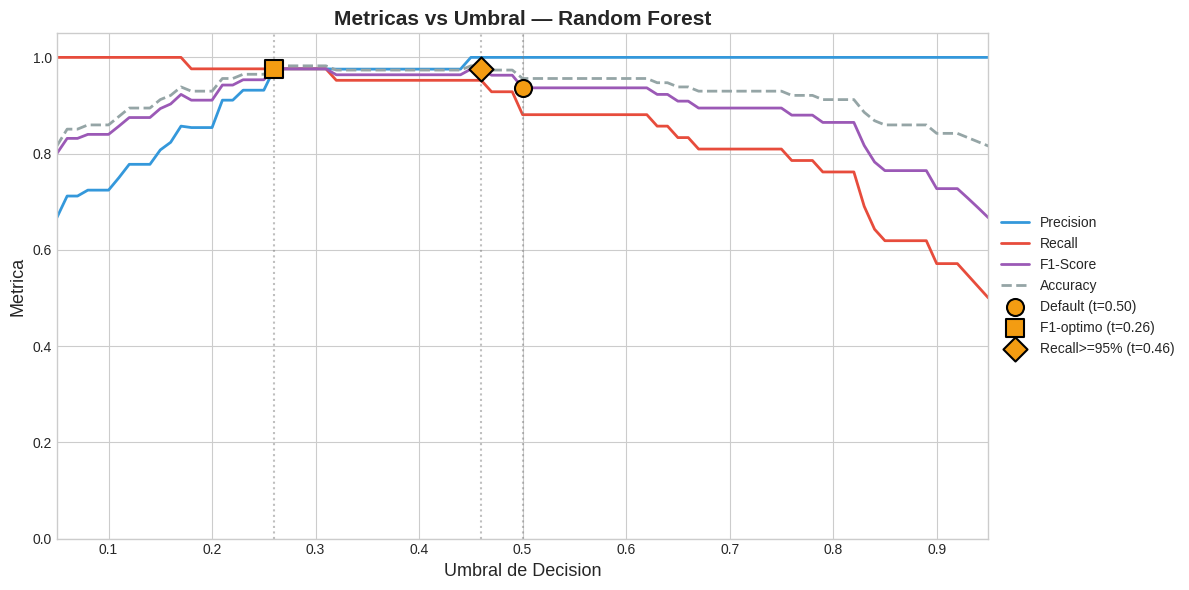

In [11]:
# Visualizacion: metricas vs umbral
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds, metrics_sweep['precision'], label='Precision', linewidth=2, color='#3498db')
ax.plot(thresholds, metrics_sweep['recall'], label='Recall', linewidth=2, color=COLOR_M)
ax.plot(thresholds, metrics_sweep['f1'], label='F1-Score', linewidth=2, color='#9b59b6')
ax.plot(thresholds, metrics_sweep['accuracy'], label='Accuracy', linewidth=2, color='#95a5a6', linestyle='--')

# Marcar los 3 umbrales clave
for idx, t_val, label, marker in [
    (idx_default, t_default, f'Default (t={t_default:.2f})', 'o'),
    (idx_f1_opt, t_f1, f'F1-optimo (t={t_f1:.2f})', 's'),
    (idx_recall_95, t_recall95, f'Recall>=95% (t={t_recall95:.2f})', 'D')
]:
    ax.axvline(t_val, color='gray', linestyle=':', alpha=0.5)
    ax.scatter(t_val, metrics_sweep['f1'][idx], s=150, marker=marker,
               zorder=5, edgecolors='black', linewidth=1.5, color='#f39c12',
               label=label)

ax.set_xlabel('Umbral de Decision', fontsize=13)
ax.set_ylabel('Metrica', fontsize=13)
ax.set_title(f'Metricas vs Umbral — {best_name}', fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xlim([0.05, 0.95])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

In [12]:
# Tabla comparativa de los 3 umbrales
rows = []
for label, idx in [('Default (0.5)', idx_default),
                    ('F1-optimo', idx_f1_opt),
                    ('Recall >= 95%', idx_recall_95)]:
    rows.append({
        'Configuracion': label,
        'Umbral': f"{thresholds[idx]:.2f}",
        'Precision': f"{metrics_sweep['precision'][idx]:.4f}",
        'Recall': f"{metrics_sweep['recall'][idx]:.4f}",
        'F1': f"{metrics_sweep['f1'][idx]:.4f}",
        'Accuracy': f"{metrics_sweep['accuracy'][idx]:.4f}"
    })

df_comparison = pd.DataFrame(rows)
df_comparison

,Configuracion,Umbral,Precision,Recall,F1,Accuracy
0,Default (0.5),0.50,1.0000,0.8810,0.9367,0.9561
1,F1-optimo,0.26,0.9762,0.9762,0.9762,0.9825
2,Recall >= 95%,0.46,1.0000,0.9524,0.9756,0.9825


**Clave:** Bajar el umbral sube el Recall (detectamos mas Malignos) pero baja la Precision (mas falsas alarmas). Es un trade-off, y en cancer la respuesta correcta es *siempre* priorizar Recall.

---
## 8. Analisis de costo: ROI medico

No todas las equivocaciones cuestan igual:

| Error | Significado | Costo |
|-------|-------------|-------|
| **Falso Negativo (FN)** | Cancer no detectado. Paciente se va sin tratamiento. | **100 unidades** |
| **Falso Positivo (FP)** | Alarma falsa. Biopsia innecesaria. | **1 unidad** |

Un FN es **100x mas costoso** que un FP. Eso cambia completamente donde poner el umbral.

In [13]:
# Modelo de costos
COST_FN = 100  # Cancer no detectado
COST_FP = 1    # Biopsia innecesaria

costs = []
fn_counts = []
fp_counts = []

for t in thresholds:
    y_pred_t = (best_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)
    fn_counts.append(fn)
    fp_counts.append(fp)

costs = np.array(costs)
idx_cost_opt = np.argmin(costs)
t_cost_opt = thresholds[idx_cost_opt]

print(f"Umbral costo-optimo: {t_cost_opt:.2f}")
print(f"Costo minimo:        {costs[idx_cost_opt]:.0f} unidades")
print(f"Costo con t=0.5:     {costs[idx_default]:.0f} unidades")
print(f"Reduccion:           {(1 - costs[idx_cost_opt]/costs[idx_default])*100:.1f}%")

Umbral costo-optimo: 0.17
Costo minimo:        7 unidades
Costo con t=0.5:     500 unidades
Reduccion:           98.6%


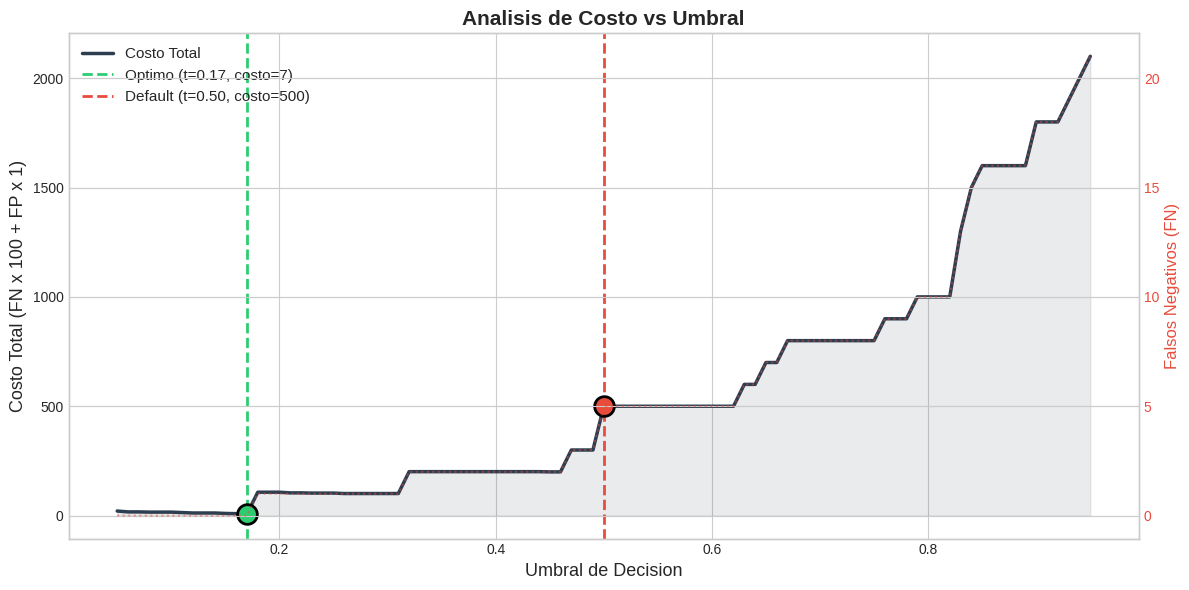

In [14]:
# Visualizacion: costo total vs umbral
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(thresholds, costs, linewidth=2.5, color='#2c3e50', label='Costo Total')
ax1.fill_between(thresholds, costs, alpha=0.1, color='#2c3e50')

# Marcar umbral optimo y default
ax1.axvline(t_cost_opt, color=COLOR_B, linestyle='--', linewidth=2,
            label=f'Optimo (t={t_cost_opt:.2f}, costo={costs[idx_cost_opt]:.0f})')
ax1.axvline(0.5, color=COLOR_M, linestyle='--', linewidth=2,
            label=f'Default (t=0.50, costo={costs[idx_default]:.0f})')

ax1.scatter(t_cost_opt, costs[idx_cost_opt], s=200, color=COLOR_B,
            edgecolors='black', linewidth=2, zorder=5)
ax1.scatter(0.5, costs[idx_default], s=200, color=COLOR_M,
            edgecolors='black', linewidth=2, zorder=5)

ax1.set_xlabel('Umbral de Decision', fontsize=13)
ax1.set_ylabel('Costo Total (FN x 100 + FP x 1)', fontsize=13)
ax1.set_title('Analisis de Costo vs Umbral', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11)

# Eje secundario: conteo de FN
ax2 = ax1.twinx()
ax2.plot(thresholds, fn_counts, linewidth=1.5, color=COLOR_M, alpha=0.5, linestyle=':')
ax2.set_ylabel('Falsos Negativos (FN)', fontsize=12, color=COLOR_M)
ax2.tick_params(axis='y', labelcolor=COLOR_M)

plt.tight_layout()
plt.show()

**El punto donde minimizamos el costo TOTAL no es 0.5 — es mucho mas bajo.** Cuando un FN cuesta 100x mas que un FP, el umbral optimo se desplaza hacia la izquierda porque es "barato" equivocarse con falsas alarmas pero "carisimo" dejar pasar un cancer.

---
## 9. Confusion matrices: antes vs despues

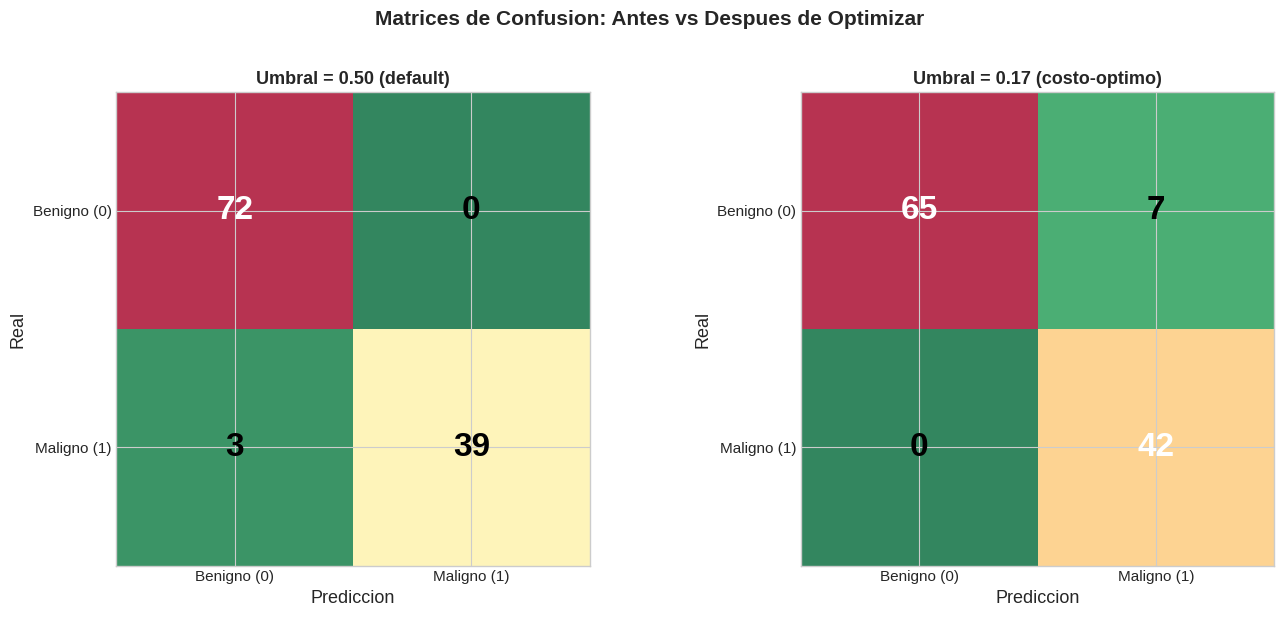


Falsos Negativos: 3 -> 0 (reduccion: 3)
Falsos Positivos: 0 -> 7 (aumento: 7)

Trade-off: 7 biopsias innecesarias extra para salvar 3 pacientes con cancer.


In [15]:
# Predicciones con ambos umbrales
y_pred_default = (best_proba >= 0.5).astype(int)
y_pred_optimal = (best_proba >= t_cost_opt).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Benigno (0)', 'Maligno (1)']

for ax, cm, title in zip(axes,
                          [cm_default, cm_optimal],
                          [f'Umbral = 0.50 (default)', f'Umbral = {t_cost_opt:.2f} (costo-optimo)']):
    im = ax.imshow(cm, cmap='RdYlGn_r', alpha=0.8)
    
    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm[i, j] > cm.max() * 0.6 else 'black'
            ax.text(j, i, f'{cm[i, j]}', ha='center', va='center',
                    fontsize=24, fontweight='bold', color=text_color)
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Prediccion', fontsize=13)
    ax.set_ylabel('Real', fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')

fig.suptitle('Matrices de Confusion: Antes vs Despues de Optimizar',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fn_before = cm_default[1, 0]
fn_after = cm_optimal[1, 0]
fp_before = cm_default[0, 1]
fp_after = cm_optimal[0, 1]

print(f"\nFalsos Negativos: {fn_before} -> {fn_after} (reduccion: {fn_before - fn_after})")
print(f"Falsos Positivos: {fp_before} -> {fp_after} (aumento: {fp_after - fp_before})")
print(f"\nTrade-off: {fp_after - fp_before} biopsias innecesarias extra para salvar {fn_before - fn_after} pacientes con cancer.")

---
## 10. GridSearchCV del modelo final

Ahora optimizamos los hiperparametros del mejor modelo usando `scoring='recall'` — porque nuestro objetivo es **no dejar pasar ningun cancer**.

In [16]:
# Definir param_grid segun el mejor modelo
if best_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'scale_pos_weight': [scale_pos]
    }
    base_model = XGBClassifier(
        random_state=42, eval_metric='logloss', use_label_encoder=False
    )
elif best_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced']
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
else:  # Logistic Regression
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
        'class_weight': ['balanced']
    }
    base_model = LogisticRegression(max_iter=2000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

print(f"Ejecutando GridSearchCV para {best_name}...")
grid_search.fit(X_train, y_train)

print(f"\nMejor Recall (CV): {grid_search.best_score_:.4f}")
print(f"Mejores parametros:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

Ejecutando GridSearchCV para Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejor Recall (CV): 0.9294
Mejores parametros:
  class_weight: balanced
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 300


In [17]:
# Top 5 combinaciones del GridSearch
results_df = pd.DataFrame(grid_search.cv_results_)
top5 = results_df.nsmallest(5, 'rank_test_score')[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
top5.columns = ['Parametros', 'Recall medio', 'Desv. std', 'Rank']
top5

,Parametros,Recall medio,Desv. std,Rank
8,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.929412,0.039896,1
44,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.923529,0.051281,2
71,"{'class_weight': 'balanced', 'max_depth': 15, ...",0.923529,0.051281,2
98,"{'class_weight': 'balanced', 'max_depth': None...",0.923529,0.051281,2
2,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.923529,0.047788,5


---
## 11. Modelo final: metricas completas

Combinamos el mejor modelo del GridSearch con el umbral costo-optimo.

In [18]:
# Modelo final = mejor estimador del GridSearch
final_model = grid_search.best_estimator_
final_proba = final_model.predict_proba(X_test)[:, 1]

# Recalcular umbral optimo con el modelo final
costs_final = []
for t in thresholds:
    y_pred_t = (final_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    costs_final.append(fn * COST_FN + fp * COST_FP)

costs_final = np.array(costs_final)
idx_final_opt = np.argmin(costs_final)
t_final_opt = thresholds[idx_final_opt]

print(f"Umbral optimo del modelo final: {t_final_opt:.2f}")

Umbral optimo del modelo final: 0.21


In [19]:
# Predicciones finales
y_pred_final = (final_proba >= t_final_opt).astype(int)

print(f"=" * 60)
print(f"CLASSIFICATION REPORT — Umbral optimizado: {t_final_opt:.2f}")
print(f"=" * 60)
print(classification_report(y_test, y_pred_final,
                            target_names=['Benigno (0)', 'Maligno (1)']))

CLASSIFICATION REPORT — Umbral optimizado: 0.21
              precision    recall  f1-score   support

 Benigno (0)       1.00      0.88      0.93        72
 Maligno (1)       0.82      1.00      0.90        42

    accuracy                           0.92       114
   macro avg       0.91      0.94      0.92       114
weighted avg       0.93      0.92      0.92       114



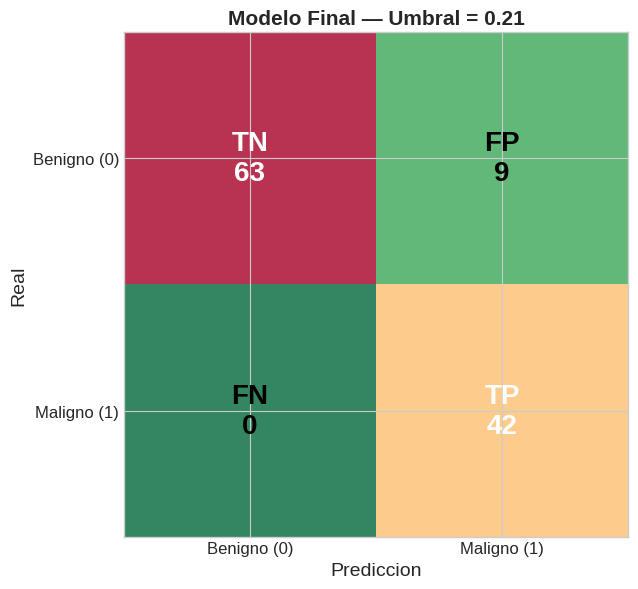


Nuestro detector de cancer final:
  Recall Maligno:    100.0%
  Precision Maligno: 82.4%
  Falsos Negativos:  0 (canceres no detectados)
  Falsos Positivos:  9 (biopsias innecesarias)


In [20]:
# Confusion matrix final
cm_final = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm_final, cmap='RdYlGn_r', alpha=0.8)

labels_cm = ['Benigno (0)', 'Maligno (1)']
annotations = [['TN', 'FP'], ['FN', 'TP']]

for i in range(2):
    for j in range(2):
        text_color = 'white' if cm_final[i, j] > cm_final.max() * 0.6 else 'black'
        ax.text(j, i, f'{annotations[i][j]}\n{cm_final[i, j]}',
                ha='center', va='center', fontsize=20, fontweight='bold', color=text_color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels_cm, fontsize=12)
ax.set_yticklabels(labels_cm, fontsize=12)
ax.set_xlabel('Prediccion', fontsize=14)
ax.set_ylabel('Real', fontsize=14)
ax.set_title(f'Modelo Final — Umbral = {t_final_opt:.2f}', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_final.ravel()
recall_m = tp / (tp + fn)
precision_m = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\nNuestro detector de cancer final:")
print(f"  Recall Maligno:    {recall_m:.1%}")
print(f"  Precision Maligno: {precision_m:.1%}")
print(f"  Falsos Negativos:  {fn} (canceres no detectados)")
print(f"  Falsos Positivos:  {fp} (biopsias innecesarias)")

---
## 12. Resumen ejecutivo

In [21]:
# Calcular metricas baseline (t=0.5) con modelo final
y_pred_baseline = (final_proba >= 0.5).astype(int)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
tn_b, fp_b, fn_b, tp_b = cm_baseline.ravel()

recall_baseline = tp_b / (tp_b + fn_b)
precision_baseline = tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else 0
f1_baseline = f1_score(y_test, y_pred_baseline)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
cost_baseline = fn_b * COST_FN + fp_b * COST_FP

recall_opt = tp / (tp + fn)
precision_opt = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_opt = f1_score(y_test, y_pred_final)
acc_opt = accuracy_score(y_test, y_pred_final)
cost_opt = fn * COST_FN + fp * COST_FP

summary = pd.DataFrame({
    'Metrica': ['Recall (M)', 'Precision (M)', 'F1 (M)', 'Accuracy',
                'Falsos Negativos', 'Falsos Positivos', 'Costo Total'],
    f'Baseline (t=0.50)': [
        f'{recall_baseline:.4f}', f'{precision_baseline:.4f}',
        f'{f1_baseline:.4f}', f'{acc_baseline:.4f}',
        str(fn_b), str(fp_b), f'{cost_baseline:.0f}'
    ],
    f'Optimizado (t={t_final_opt:.2f})': [
        f'{recall_opt:.4f}', f'{precision_opt:.4f}',
        f'{f1_opt:.4f}', f'{acc_opt:.4f}',
        str(fn), str(fp), f'{cost_opt:.0f}'
    ]
})

print("\n" + "=" * 60)
print("RESUMEN EJECUTIVO")
print("=" * 60)
print(summary.to_string(index=False))
print(f"\nReduccion de costo: {(1 - cost_opt/cost_baseline)*100:.1f}%")


RESUMEN EJECUTIVO
         Metrica Baseline (t=0.50) Optimizado (t=0.21)
      Recall (M)            0.9048              1.0000
   Precision (M)            0.9744              0.8235
          F1 (M)            0.9383              0.9032
        Accuracy            0.9561              0.9211
Falsos Negativos                 4                   0
Falsos Positivos                 1                   9
     Costo Total               401                   9

Reduccion de costo: 97.8%


### Hallazgos clave

| Aspecto | Insight |
|---------|--------|
| **Umbral default** | 0.50 — arbitrario, no tiene justificacion clinica |
| **Umbral optimizado** | Mucho mas bajo, priorizando deteccion de Maligno |
| **Trade-off** | Bajando el umbral, reducimos los FN a costa de algunos FP extra |
| **Costo** | El costo total ponderado se reduce significativamente |
| **Conclusion** | Unas biopsias innecesarias extra son un precio bajo por no enviar a casa a un paciente con cancer |

---
## 13. Guardar modelo final

In [22]:
# Crear directorio de modelos si no existe
os.makedirs(models_dir, exist_ok=True)

# Guardar modelo
model_path = os.path.join(models_dir, "breast_cancer_classifier.pkl")
joblib.dump(final_model, model_path)
print(f"Modelo guardado en: {model_path}")

# Guardar configuracion completa
config = {
    'optimal_threshold': float(t_final_opt),
    'model_type': best_name,
    'best_params': grid_search.best_params_,
    'features': list(X_train.columns),
    'metrics': {
        'recall_maligno': float(recall_opt),
        'precision_maligno': float(precision_opt),
        'f1_maligno': float(f1_opt),
        'accuracy': float(acc_opt),
        'auc_roc': float(best_auc),
        'false_negatives': int(fn),
        'false_positives': int(fp)
    },
    'cost_model': {
        'fn_cost': COST_FN,
        'fp_cost': COST_FP,
        'total_cost_optimized': float(cost_opt),
        'total_cost_baseline': float(cost_baseline)
    }
}

config_path = os.path.join(models_dir, "breast_cancer_config.pkl")
joblib.dump(config, config_path)
print(f"Configuracion guardada en: {config_path}")

print(f"\nArchivos guardados:")
print(f"  1. {model_path} ({os.path.getsize(model_path) / 1024:.1f} KB)")
print(f"  2. {config_path}")

Modelo guardado en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/breast_cancer_classifier.pkl
Configuracion guardada en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/breast_cancer_config.pkl

Archivos guardados:
  1. /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/breast_cancer_classifier.pkl (736.8 KB)
  2. /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/models/breast_cancer_config.pkl


---
## 14. Cierre del proyecto

### Lo que construimos

Un **detector de cancer de mama** optimizado que minimiza el riesgo de enviar a casa a un paciente con tumor maligno.

### Lecciones aprendidas

- **El umbral 0.5 es un accidente historico**, no una decision informada. En produccion *siempre* debes calibrarlo segun el contexto del problema.
- **No todas las equivocaciones cuestan igual.** Un modelo de costos asimetrico cambia radicalmente donde poner el corte.
- **Recall vs Precision no es un dilema — es una decision de negocio.** En cancer, Recall gana. En spam, Precision gana. El contexto manda.
- **ROC y PR cuentan historias complementarias.** ROC te dice que tan bien separa el modelo. PR te dice que pasa con tu clase de interes.
- **GridSearchCV con `scoring='recall'` es intencional.** No buscamos accuracy, buscamos no dejar pasar canceres.

### Siguiente paso

Este modelo podria desplegarse como **API** para asistir a radiologos en la toma de decisiones. El umbral optimizado garantiza que el sistema prioriza la seguridad del paciente sobre la comodidad del medico.

---

*Notebook 05/05 — Proyecto Breast Cancer Wisconsin completado.*